In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.visualization import simple_norm

%matplotlib widget

plt.rcParams.update({'font.size': 16})

import sys
print(sys.version)
print(sys.executable)

3.13.3 | packaged by conda-forge | (main, Apr 14 2025, 20:44:03) [GCC 13.3.0]
/home/firestar/.miniconda/bin/python


In [10]:
file = "CRAFTS_RA60_140_DEC-13_2_-_moment1"
output_file = file + ".png"

hdul = fits.open(file + ".fits")
hdr = hdul[0].header
data = hdul[0].data
data[data == 0] = np.nan

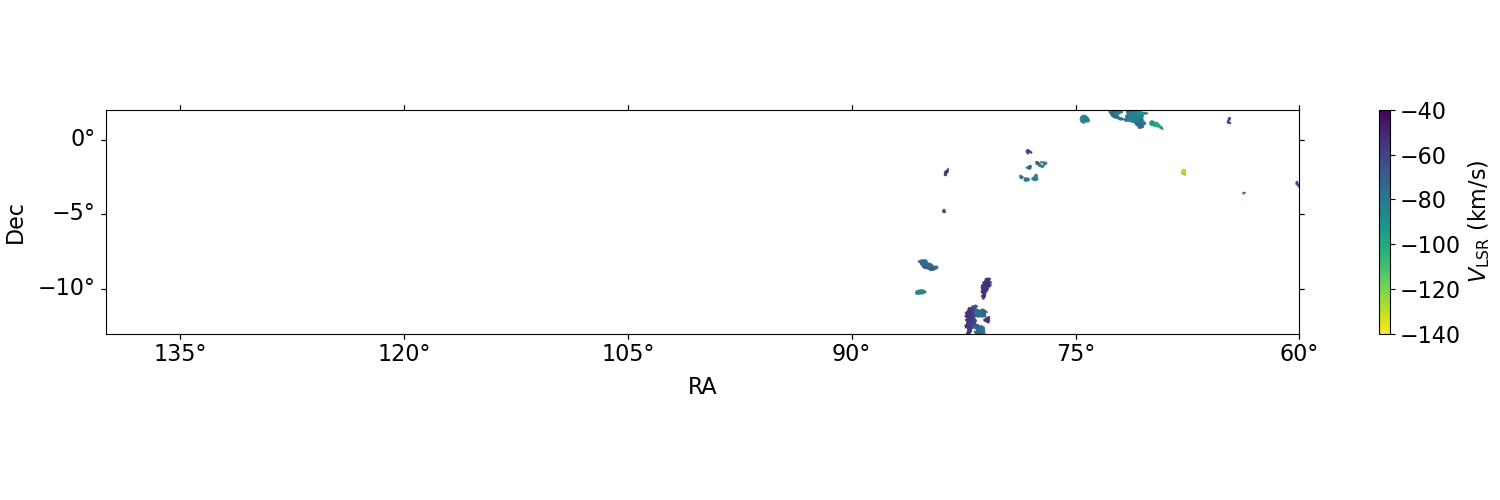

In [12]:
def displayimage(img, wcs, output_file):
    fig, ax = plt.subplots(
        figsize=(15, 5), layout="compressed", subplot_kw={"projection": wcs}
    )
    norm = simple_norm(np.array(img), vmin=-140, vmax=-40, stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis_r", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    plt.colorbar(im, ticks=np.arange(-140,-20,20), label=r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
    plt.savefig(output_file, bbox_inches="tight", dpi=300)
    plt.show()

displayimage(data, WCS(hdr), output_file)